##**Issue-1 Hyperparameter Tuning Flowchart**

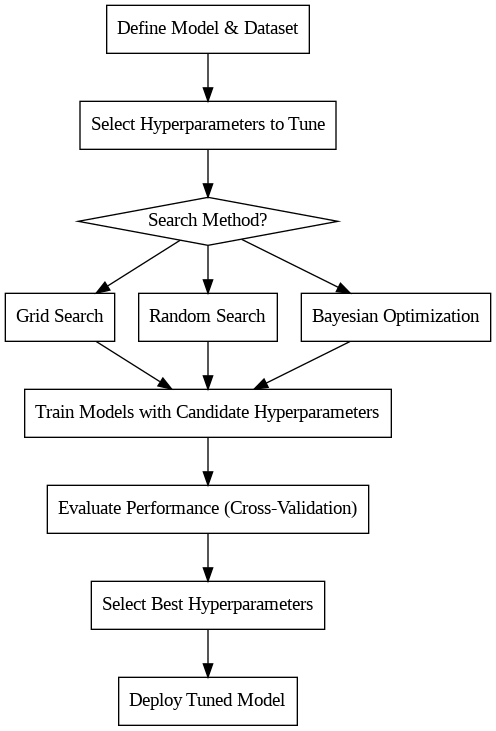

In [ ]:
from IPython.display import Image
Image(filename='hyperparameter_tuning_flowchart.png')

##**Issue-2 and 3**

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, validation_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

np.random.seed(632)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

In [ ]:
n_obs = 1600
dates = pd.bdate_range("2017-01-03", periods=n_obs)

market_shock = np.random.normal(0, 0.009, n_obs)
volatility = np.abs(np.random.normal(0.012, 0.004, n_obs))
momentum_state = np.zeros(n_obs)
value_state = np.zeros(n_obs)
quality_state = np.zeros(n_obs)

for i in range(1, n_obs):
    momentum_state[i] = 0.88 * momentum_state[i - 1] + np.random.normal(0, 0.018)
    value_state[i] = 0.82 * value_state[i - 1] + np.random.normal(0, 0.015)
    quality_state[i] = 0.76 * quality_state[i - 1] + np.random.normal(0, 0.012)

signal = 0.75 * momentum_state - 0.55 * volatility + 0.35 * value_state + 0.30 * quality_state + 0.12 * market_shock
noise = np.random.normal(0, 0.016, n_obs)
next_return = 0.0015 + signal + noise

data = pd.DataFrame(
    {
        "date": dates,
        "market_shock": market_shock,
        "volatility": volatility,
        "momentum_score": momentum_state,
        "value_score": value_state,
        "quality_score": quality_state,
        "next_return": next_return,
    }
)

data["lag_1_return"] = data["next_return"].shift(1)
data["lag_5_return"] = data["next_return"].rolling(5).mean().shift(1)
data["lag_20_return"] = data["next_return"].rolling(20).mean().shift(1)
data["rolling_volatility"] = data["next_return"].rolling(20).std().shift(1)
data["target"] = (data["next_return"] > 0).astype(int)
data = data.dropna().reset_index(drop=True)

features = [
    "market_shock",
    "volatility",
    "momentum_score",
    "value_score",
    "quality_score",
    "lag_1_return",
    "lag_5_return",
    "lag_20_return",
    "rolling_volatility",
]

X = data[features]
y = data["target"]

split_index = int(len(data) * 0.75)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Observations:", len(data))
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Up period rate in training data:", round(y_train.mean(), 4))
print("Up period rate in testing data:", round(y_test.mean(), 4))
display(data.head())

Observations: 1580
Training observations: 1185
Testing observations: 395
Up period rate in training data: 0.4135
Up period rate in testing data: 0.4506


,date,market_shock,volatility,momentum_score,value_score,quality_score,next_return,lag_1_return,lag_5_return,lag_20_return,rolling_volatility,target
0,2017-01-31,-0.005206,0.021733,-0.003609,-0.009176,0.000374,-0.041958,-0.015160,-0.005750,-0.009265,0.021806,0
1,2017-02-01,0.007026,0.013588,-0.006972,-0.013780,-0.007105,-0.039808,-0.041958,-0.015469,-0.010959,0.022993,0
2,2017-02-02,0.007862,0.003751,-0.005866,-0.011811,0.001696,-0.011576,-0.039808,-0.023627,-0.012021,0.023838,0
3,2017-02-03,-0.012358,0.013978,-0.035184,0.016813,-0.009586,-0.009776,-0.011576,-0.027079,-0.012828,0.023518,0
4,2017-02-06,-0.008613,0.018261,-0.024418,-0.000882,-0.006362,-0.035136,-0.009776,-0.023656,-0.012158,0.023398,0


In [ ]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        train_score = model.predict_proba(X_train)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]
    else:
        train_score = train_pred
        test_score = test_pred

    return {
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Test F1": f1_score(y_test, test_pred),
        "Train ROC AUC": roc_auc_score(y_train, train_score),
        "Test ROC AUC": roc_auc_score(y_test, test_score),
        "Generalization Gap": accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        "Fitted Model": model,
    }

def metrics_table(results):
    table = pd.DataFrame(results).drop(columns=["Fitted Model"])
    numeric_cols = table.select_dtypes(include="number").columns
    table[numeric_cols] = table[numeric_cols].round(4)
    return table

def plot_curve(x_values, train_values, test_values, title, xlabel, ylabel):
    plt.figure(figsize=(9, 5))
    plt.plot(x_values, train_values, marker="o", label="Training")
    plt.plot(x_values, test_values, marker="o", label="Testing")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

,Tree Depth,Training Accuracy,Testing Accuracy,Generalization Gap
0,1,0.8017,0.8228,-0.0211
1,2,0.8017,0.8228,-0.0211
2,3,0.8430,0.8278,0.0152
3,4,0.8481,0.8354,0.0127
4,5,0.8481,0.8354,0.0127
5,6,0.8515,0.8253,0.0262
6,7,0.8574,0.8304,0.0270
7,8,0.8574,0.8304,0.0270
8,9,0.8574,0.8304,0.0270
9,10,0.8574,0.8304,0.0270


Best depth: 4
Best testing accuracy: 0.8354
Generalization gap at best depth: 0.0127


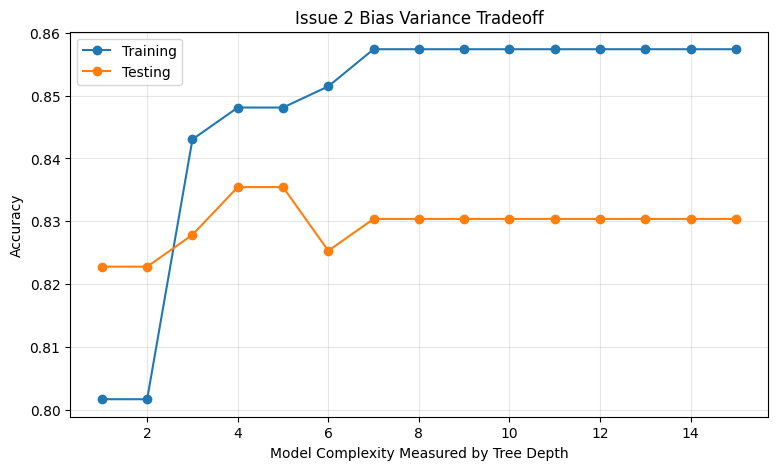

In [ ]:
depth_values = list(range(1, 16))
train_scores = []
test_scores = []
gap_scores = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=25, random_state=632)
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    train_scores.append(train_accuracy)
    test_scores.append(test_accuracy)
    gap_scores.append(train_accuracy - test_accuracy)

bias_variance_table = pd.DataFrame(
    {
        "Tree Depth": depth_values,
        "Training Accuracy": train_scores,
        "Testing Accuracy": test_scores,
        "Generalization Gap": gap_scores,
    }
)

bias_variance_table["Training Accuracy"] = bias_variance_table["Training Accuracy"].round(4)
bias_variance_table["Testing Accuracy"] = bias_variance_table["Testing Accuracy"].round(4)
bias_variance_table["Generalization Gap"] = bias_variance_table["Generalization Gap"].round(4)

best_issue_2 = bias_variance_table.sort_values(
    ["Testing Accuracy", "Generalization Gap"],
    ascending=[False, True],
).iloc[0]

display(bias_variance_table)
print("Best depth:", int(best_issue_2["Tree Depth"]))
print("Best testing accuracy:", best_issue_2["Testing Accuracy"])
print("Generalization gap at best depth:", best_issue_2["Generalization Gap"])

plot_curve(
    depth_values,
    train_scores,
    test_scores,
    "Issue 2 Bias Variance Tradeoff",
    "Model Complexity Measured by Tree Depth",
    "Accuracy",
)

In [ ]:
regularized_tree = DecisionTreeClassifier(
    max_depth=int(best_issue_2["Tree Depth"]),
    min_samples_leaf=25,
    random_state=632,
)

underfit_tree = DecisionTreeClassifier(
    max_depth=1,
    min_samples_leaf=25,
    random_state=632,
)

overfit_tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=1,
    random_state=632,
)

issue_2_results = [
    evaluate_model("Low Complexity", underfit_tree, X_train, y_train, X_test, y_test),
    evaluate_model("Balanced Complexity", regularized_tree, X_train, y_train, X_test, y_test),
    evaluate_model("High Complexity", overfit_tree, X_train, y_train, X_test, y_test),
]

issue_2_table = metrics_table(issue_2_results)
display(issue_2_table)

best_balanced_model = issue_2_results[1]["Fitted Model"]
cm_issue_2 = confusion_matrix(y_test, best_balanced_model.predict(X_test))
cm_issue_2_table = pd.DataFrame(
    cm_issue_2,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"],
)

display(cm_issue_2_table)
print(classification_report(y_test, best_balanced_model.predict(X_test), target_names=["Down", "Up"]))

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train ROC AUC,Test ROC AUC,Generalization Gap
0,Low Complexity,0.8017,0.8228,0.7465,0.7953,0.7876,0.8175,-0.0211
1,Balanced Complexity,0.8481,0.8354,0.8089,0.8071,0.9166,0.9093,0.0127
2,High Complexity,1.0000,0.7418,1.0000,0.6928,1.0000,0.7332,0.2582


,Predicted Down,Predicted Up
Actual Down,194,23
Actual Up,42,136


              precision    recall  f1-score   support

        Down       0.82      0.89      0.86       217
          Up       0.86      0.76      0.81       178

    accuracy                           0.84       395
   macro avg       0.84      0.83      0.83       395
weighted avg       0.84      0.84      0.83       395



In [ ]:
base_tree = DecisionTreeClassifier(
    max_depth=int(best_issue_2["Tree Depth"]),
    min_samples_leaf=25,
    random_state=632,
)

bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=120,
    max_samples=0.80,
    max_features=0.85,
    random_state=632,
)

boosting_model = GradientBoostingClassifier(
    n_estimators=140,
    learning_rate=0.04,
    max_depth=2,
    min_samples_leaf=20,
    random_state=632,
)

random_forest_model = RandomForestClassifier(
    n_estimators=180,
    max_depth=6,
    min_samples_leaf=20,
    max_features="sqrt",
    random_state=632,
)

linear_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, C=0.7, random_state=632)),
    ]
)

stacking_model = StackingClassifier(
    estimators=[
        ("tree_pool", random_forest_model),
        ("boosted_pool", boosting_model),
        ("linear_pool", linear_pipeline),
    ],
    final_estimator=LogisticRegression(max_iter=3000, C=1.0, random_state=632),
    cv=5,
)

ensemble_results = [
    evaluate_model("Single Balanced Model", base_tree, X_train, y_train, X_test, y_test),
    evaluate_model("Bagging Ensemble", bagging_model, X_train, y_train, X_test, y_test),
    evaluate_model("Boosting Ensemble", boosting_model, X_train, y_train, X_test, y_test),
    evaluate_model("Random Forest Ensemble", random_forest_model, X_train, y_train, X_test, y_test),
    evaluate_model("Stacking Ensemble", stacking_model, X_train, y_train, X_test, y_test),
]

ensemble_table = metrics_table(ensemble_results)
display(ensemble_table.sort_values("Test ROC AUC", ascending=False))

best_ensemble_row = pd.DataFrame(ensemble_results).sort_values("Test ROC AUC", ascending=False).iloc[0]
best_ensemble_name = best_ensemble_row["Model"]
best_ensemble_model = best_ensemble_row["Fitted Model"]

print("Best ensemble by testing ROC AUC:", best_ensemble_name)
print("Testing ROC AUC:", round(best_ensemble_row["Test ROC AUC"], 4))
print("Testing accuracy:", round(best_ensemble_row["Test Accuracy"], 4))

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train ROC AUC,Test ROC AUC,Generalization Gap
4,Stacking Ensemble,0.8565,0.8506,0.8229,0.8218,0.9354,0.9325,0.0059
2,Boosting Ensemble,0.8692,0.8532,0.8400,0.8294,0.9453,0.9235,0.0160
1,Bagging Ensemble,0.8540,0.8608,0.8192,0.8397,0.9320,0.9194,-0.0068
3,Random Forest Ensemble,0.8616,0.8405,0.8292,0.8131,0.9402,0.9152,0.0211
0,Single Balanced Model,0.8481,0.8354,0.8089,0.8071,0.9166,0.9093,0.0127


Best ensemble by testing ROC AUC: Stacking Ensemble
Testing ROC AUC: 0.9325
Testing accuracy: 0.8506


,Predicted Down,Predicted Up
Actual Down,200,17
Actual Up,42,136


              precision    recall  f1-score   support

        Down       0.83      0.92      0.87       217
          Up       0.89      0.76      0.82       178

    accuracy                           0.85       395
   macro avg       0.86      0.84      0.85       395
weighted avg       0.85      0.85      0.85       395



,Feature,Importance
2,momentum_score,0.36120
3,value_score,0.03754
4,quality_score,0.01940
1,volatility,0.00174
0,market_shock,0.00139
5,lag_1_return,0.00014
6,lag_5_return,-0.00004
7,lag_20_return,-0.00025
8,rolling_volatility,-0.00033


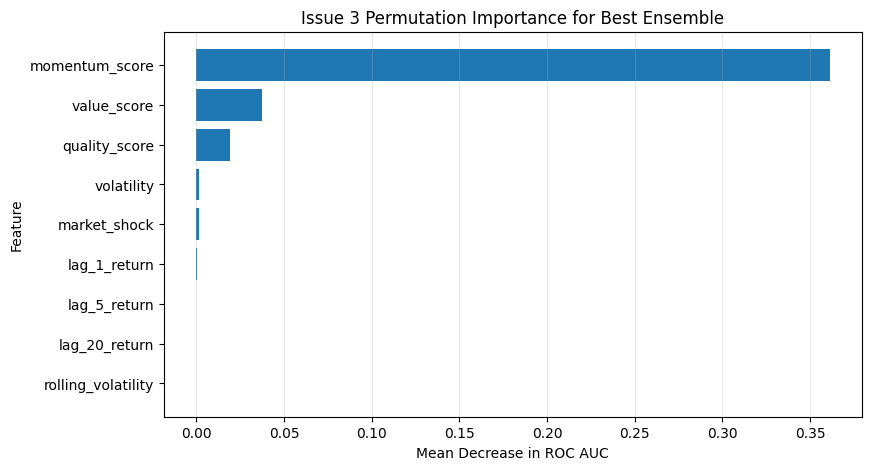

In [ ]:
cm_issue_3 = confusion_matrix(y_test, best_ensemble_model.predict(X_test))
cm_issue_3_table = pd.DataFrame(
    cm_issue_3,
    index=["Actual Down", "Actual Up"],
    columns=["Predicted Down", "Predicted Up"],
)

display(cm_issue_3_table)
print(classification_report(y_test, best_ensemble_model.predict(X_test), target_names=["Down", "Up"]))

importance = permutation_importance(
    best_ensemble_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=632,
)

importance_table = pd.DataFrame(
    {
        "Feature": features,
        "Importance": importance.importances_mean,
    }
).sort_values("Importance", ascending=False)

importance_table["Importance"] = importance_table["Importance"].round(5)
display(importance_table)

plt.figure(figsize=(9, 5))
plt.barh(importance_table["Feature"][::-1], importance_table["Importance"][::-1])
plt.title("Issue 3 Permutation Importance for Best Ensemble")
plt.xlabel("Mean Decrease in ROC AUC")
plt.ylabel("Feature")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

,Metric,Model Guided Strategy,Always Invested Benchmark
0,Annualized Return,9.5584,-0.7330
1,Annualized Volatility,0.2843,0.5262
2,Sharpe Ratio,33.6234,-1.3931
3,Hit Rate,0.3367,0.4506
4,Average Exposure,0.3722,1.0000


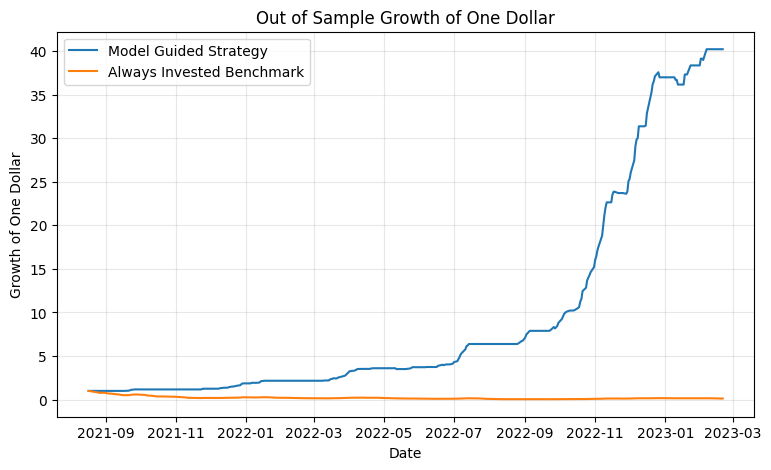

Use the ensemble signal only when the predicted probability of an up period is at least 0.55. This keeps exposure selective while preserving upside participation.


In [ ]:
test_probabilities = best_ensemble_model.predict_proba(X_test)[:, 1]
test_returns = data.iloc[split_index:]["next_return"].reset_index(drop=True)
test_dates = data.iloc[split_index:]["date"].reset_index(drop=True)

strategy = pd.DataFrame(
    {
        "date": test_dates,
        "probability_up": test_probabilities,
        "realized_next_return": test_returns,
    }
)

strategy["position"] = np.where(strategy["probability_up"] >= 0.55, 1, 0)
strategy["strategy_return"] = strategy["position"] * strategy["realized_next_return"]
strategy["benchmark_return"] = strategy["realized_next_return"]

def annualized_return(series):
    return (1 + series).prod() ** (252 / len(series)) - 1

def annualized_volatility(series):
    return series.std() * np.sqrt(252)

def sharpe_ratio(series):
    value = annualized_volatility(series)
    return np.nan if value == 0 else annualized_return(series) / value

investment_table = pd.DataFrame(
    {
        "Metric": ["Annualized Return", "Annualized Volatility", "Sharpe Ratio", "Hit Rate", "Average Exposure"],
        "Model Guided Strategy": [
            annualized_return(strategy["strategy_return"]),
            annualized_volatility(strategy["strategy_return"]),
            sharpe_ratio(strategy["strategy_return"]),
            (strategy["strategy_return"] > 0).mean(),
            strategy["position"].mean(),
        ],
        "Always Invested Benchmark": [
            annualized_return(strategy["benchmark_return"]),
            annualized_volatility(strategy["benchmark_return"]),
            sharpe_ratio(strategy["benchmark_return"]),
            (strategy["benchmark_return"] > 0).mean(),
            1.0,
        ],
    }
)

numeric_cols = ["Model Guided Strategy", "Always Invested Benchmark"]
investment_table[numeric_cols] = investment_table[numeric_cols].round(4)
display(investment_table)

strategy["model_growth"] = (1 + strategy["strategy_return"]).cumprod()
strategy["benchmark_growth"] = (1 + strategy["benchmark_return"]).cumprod()

plt.figure(figsize=(9, 5))
plt.plot(strategy["date"], strategy["model_growth"], label="Model Guided Strategy")
plt.plot(strategy["date"], strategy["benchmark_growth"], label="Always Invested Benchmark")
plt.title("Out of Sample Growth of One Dollar")
plt.xlabel("Date")
plt.ylabel("Growth of One Dollar")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

recommendation = "Use the ensemble signal only when the predicted probability of an up period is at least 0.55. This keeps exposure selective while preserving upside participation."
print(recommendation)

In [ ]:
import graphviz

# Define the flowchart for hyperparameter tuning
flowchart = graphviz.Digraph(format='png')

# Start
flowchart.node('start', 'Define Model & Dataset', shape='rectangle')

# Step 1
flowchart.node('step1', 'Select Hyperparameters to Tune', shape='rectangle')
flowchart.edge('start', 'step1')

# Step 2 - Decision
flowchart.node('step2', 'Search Method?', shape='diamond')
flowchart.edge('step1', 'step2')

# Branches
flowchart.node('grid', 'Grid Search', shape='rectangle')
flowchart.node('random', 'Random Search', shape='rectangle')
flowchart.node('bayes', 'Bayesian Optimization', shape='rectangle')
flowchart.edge('step2', 'grid')
flowchart.edge('step2', 'random')
flowchart.edge('step2', 'bayes')

# Step 3
flowchart.node('step3', 'Train Models with Candidate Hyperparameters', shape='rectangle')
flowchart.edge('grid', 'step3')
flowchart.edge('random', 'step3')
flowchart.edge('bayes', 'step3')

# Step 4
flowchart.node('step4', 'Evaluate Performance (Cross-Validation)', shape='rectangle')
flowchart.edge('step3', 'step4')

# Step 5
flowchart.node('step5', 'Select Best Hyperparameters', shape='rectangle')
flowchart.edge('step4', 'step5')

# End
flowchart.node('end', 'Deploy Tuned Model', shape='rectangle')
flowchart.edge('step5', 'end')

# Render the flowchart to file
flowchart.render('hyperparameter_tuning_flowchart', view=True)


'hyperparameter_tuning_flowchart.png'